# Evaluasi Performa Real-Time CASME II
Notebook ini menghitung kecepatan inferensi (latency/real-time performance) untuk dataset CASME II secara *end-to-end* tanpa melihat performa klasifikasi. Pipeline mengikuti arsitektur WebSocket streaming/backend.

In [1]:
import os
os.environ['MODEL_N_TTA'] = '1'
os.environ['MODEL_STRICT_NOTEBOOK_PARITY'] = '0'

import os
import glob
import time
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# pulse-live modules
import sys
sys.path.append("..")
from src.face.modules import FaceLandmark, FaceRoiPoints
from src.face.modules.face_aligner import FaceAligner
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhaseSpotterROI, ApexSmoother
from src.models.inferencer import load_inferencer_from_env


In [2]:
# Inisialisasi Modul
landmarker = FaceLandmark()
aligner = FaceAligner()
tvl1 = TVL1(fast_mode=True)
phase_spotter = ApexPhaseSpotterROI()

# Inisialisasi Model Inferensi
try:
    inf = load_inferencer_from_env()
    print(f"Model loaded successfully: {type(inf).__name__}")
except Exception as e:
    print(f"Failed to load inferencer: {e}")
    inf = None

# Warm-up GPU untuk menghindari Cold Start (200ms+) di awal
if inf is not None:
    print("Warming up GPU...")
    max_t = getattr(inf, 'max_seq_len', 150)
    dummy_flow = np.zeros((max_t, 5, 2, 32, 32), dtype=np.float32)
    import torch
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False # Matikan autotuner agar tidak mencari algoritma baru tiap frame berubah
        torch.cuda.synchronize()

    _ = inf.predict_flow(dummy_flow)
    print("Warm-up selesai!")


W0000 00:00:1782644569.052390  225794 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644569.102752  225794 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782644569.105605  225819 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782644569.107715  225795 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644569.118018  225810 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644569.133802  225821 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644569.138266  225821 gl_context_eg

Model loaded successfully: SpatioTemporalInferencer
Warming up GPU...


W0000 00:00:1782644569.305727  225849 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644569.309544  225849 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782644569.311189  225872 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782644569.313096  225854 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644569.325935  225862 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Warm-up selesai!


In [3]:
samm_dir = "/home/inadio/datasets/secondaries/samm"
video_dirs = [d for d in glob.glob(os.path.join(samm_dir, "*", "*")) if os.path.isdir(d)]
print(f"Found {len(video_dirs)} videos in CASME II dataset.")

roi_defs = [
    frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
    frozenset(FaceRoiPoints.LIPS_POINTS),
    frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS),
]
tile_size = (32, 32)
margin = 0.05
cols = 3
rows = int(np.ceil(len(roi_defs) / cols))

latency_data = []

# Untuk mempercepat, kita ambil subset (misal: 20 video pertama)
for i, video_dir in enumerate(video_dirs[:50]):
    import glob
    frames = []
    img_paths = sorted(glob.glob(os.path.join(video_dir, "*.jpg")))
    for img_path in img_paths:
        frame = cv2.imread(img_path)
        if frame is not None:
            frames.append(frame)
    
    if len(frames) == 0:
        continue
        
    last_crops = None
    magnitudes = []
    flows = []
    
    video_latencies = {
        "landmark": [],
        "flow": [],
    }
    
    for frame in frames:
        # Landmark & ROI
        start_landmark = time.time()
        landmarks = landmarker.detect(frame)
        try:
            aligned, aligned_landmarks = aligner.align_with_landmarks(image=frame, landmarks=landmarks)
        except Exception:
            aligned = frame
            aligned_landmarks = landmarks
            
        crops = []
        for roi_points in roi_defs:
            try:
                roi, _ = landmarker.crop_roi(
                    image=frame,
                    landmark_result=aligned_landmarks,
                    roi_points=roi_points,
                    margin=margin,
                    target_size=tile_size,
                )
            except Exception:
                roi = np.zeros((tile_size[1], tile_size[0], 3), dtype=np.uint8)
            crops.append(roi)
        video_latencies["landmark"].append((time.time() - start_landmark) * 1000)
        
        # TVL1 Flow
        if last_crops is not None:
            start_flow = time.time()
            pairs = list(zip(last_crops, crops))
            flows_batch = tvl1.compute_batch(pairs, download=True)
            
            flow_canvas = np.zeros(
                (rows * tile_size[1], cols * tile_size[0], 2),
                dtype=np.float32,
            )
            roi_magnitudes = []
            for idx, flow in enumerate(flows_batch):
                r, c = divmod(idx, cols)
                y1, y2 = r * tile_size[1], (r + 1) * tile_size[1]
                x1, x2 = c * tile_size[0], (c + 1) * tile_size[0]
                flow_canvas[y1:y2, x1:x2, :] = flow
                roi_magnitudes.append(float(np.mean(np.hypot(flow[..., 0], flow[..., 1]))))
            
            mag = float(np.mean(roi_magnitudes))
            video_latencies["flow"].append((time.time() - start_flow) * 1000)
            
            magnitudes.append(mag)
            flows.append(flow_canvas)
            
        last_crops = crops
        
    # Spotting & Inference
    if inf is None or len(magnitudes) == 0:
        continue
        
    start_spot = time.time()
    from scipy.signal import savgol_filter
    try:
        window_length = ApexSmoother.calculate_window_length(len(magnitudes))
        polyorder = ApexSmoother.calculate_polyorder(window_length)
        smoothed = [float(x) for x in savgol_filter(magnitudes, window_length, polyorder)]
        windows, meta = phase_spotter.detect_windows_from_signal(magnitudes)
    except Exception:
        pass
    spotting_latency = (time.time() - start_spot) * 1000
    
    n_roi = len(roi_defs)
    frames_for_inf = []
    for canvas in flows:
        canvas = np.asarray(canvas, dtype=np.float32)
        tiles = []
        for idx in range(n_roi):
            r, c = divmod(idx, cols)
            y1, y2 = r * tile_size[1], (r + 1) * tile_size[1]
            x1, x2 = c * tile_size[0], (c + 1) * tile_size[0]
            tiles.append(canvas[y1:y2, x1:x2, :].transpose(2, 0, 1))
        frames_for_inf.append(np.stack(tiles, axis=0))
        
    flow_array = np.stack(frames_for_inf, axis=0) # (T, N_roi, 2, H, W)
    
    start_infer = time.time()
    result = inf.predict_flow(flow_array)
    infer_latency = (time.time() - start_infer) * 1000
    
    latency_data.append({
        "video": os.path.basename(video_dir),
        "landmark_avg_ms": np.mean(video_latencies["landmark"]),
        "flow_avg_ms": np.mean(video_latencies["flow"]),
        "spotting_ms": spotting_latency,
        "model_infer_ms": infer_latency,
    })
    
    if i % 5 == 0:
        print(f"Processed {i+1} videos...")
        
df = pd.DataFrame(latency_data)
df.head()


Found 159 videos in CASME II dataset.


W0000 00:00:1782644571.856501  225909 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644571.859886  225909 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782644571.862007  225932 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782644571.864664  225911 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644571.877042  225915 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processed 1 videos...


W0000 00:00:1782644574.338938  225952 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644574.343102  225952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782644574.344685  225975 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782644574.347262  225953 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644574.360032  225966 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644576.948130  225980 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644576.951020  225980 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

Processed 6 videos...


...

Processed 41 videos...


W0000 00:00:1782644666.166460  228017 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644666.168783  228017 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782644666.170058  228040 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782644666.171770  228023 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644666.181981  228031 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644667.458502  228045 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644667.461294  228045 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

Processed 46 videos...


W0000 00:00:1782644677.851459  228297 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644677.853995  228297 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782644677.855915  228320 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782644677.857867  228300 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644677.866544  228305 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782644679.495733  228349 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782644679.499342  228349 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

,video,landmark_avg_ms,flow_avg_ms,spotting_ms,model_infer_ms
0,006_1_2,13.792978,14.931699,1.151323,30.657053
1,006_1_3,13.428830,15.368713,0.972271,33.468962
2,006_1_4,13.425538,15.916498,0.918388,27.482033
3,006_1_5,13.494055,15.281813,0.959158,25.395870
4,006_1_6,12.989502,13.531196,0.954866,31.725645


Total end-to-end latency: 54.95 ms
Rata-rata FPS (berdasarkan pipeline penuh, 1 window): 18.20 FPS


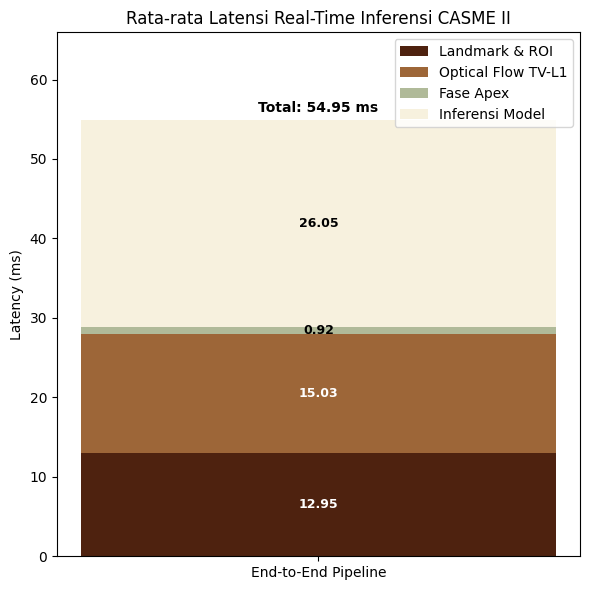

In [4]:
stages = [
    "Landmark & ROI",
    "Optical Flow TV-L1",
    "Fase Apex",
    "Inferensi Model"
]

latency = [
    df["landmark_avg_ms"].mean(),
    df["flow_avg_ms"].mean(),
    df["spotting_ms"].mean(),
    df["model_infer_ms"].mean()
]

total_latency = sum(latency)
print(f"Total end-to-end latency: {total_latency:.2f} ms")
print(f"Rata-rata FPS (berdasarkan pipeline penuh, 1 window): {1000/total_latency:.2f} FPS")

fig, ax = plt.subplots(figsize=(6, 6))
bottom = 0
colors = ["#4E220F", "#9D6638", "#B0BA99", "#F7F1DE"]

for i in range(len(stages)):
    ax.bar(
        "End-to-End Pipeline",
        latency[i],
        bottom=bottom,
        label=stages[i],
        color=colors[i]
    )
    ax.text(
        0,
        bottom + latency[i] / 2,
        f"{latency[i]:.2f}",
        ha="center", va="center", fontsize=9,
        color="white" if i < 2 else "black", fontweight="bold"
    )
    bottom += latency[i]

ax.text(
    0, total_latency + 1,
    f"Total: {total_latency:.2f} ms",
    ha="center", fontsize=10, fontweight="bold"
)
ax.set_ylabel("Latency (ms)")
ax.legend(loc="upper right")
ax.set_ylim(0, total_latency + max(10, total_latency*0.2))
plt.title("Rata-rata Latensi Real-Time Inferensi CASME II")
plt.tight_layout()
plt.show()


In [ ]:
print(df)

       video  landmark_avg_ms  flow_avg_ms  spotting_ms  model_infer_ms
0    006_1_2        13.792978    14.931699     1.151323       30.657053
1    006_1_3        13.428830    15.368713     0.972271       33.468962
2    006_1_4        13.425538    15.916498     0.918388       27.482033
3    006_1_5        13.494055    15.281813     0.959158       25.395870
4    006_1_6        12.989502    13.531196     0.954866       31.725645
5    006_2_4        12.440940    12.561862     0.931740       18.726110
6    006_3_4        12.748577    13.305172     0.893116       25.866985
7    006_3_5        13.023864    13.359284     0.911236       31.026363
8   006_5_10        12.388942    15.413232     0.858307       25.484324
9   006_5_11        12.784272    14.790083     0.917912       26.392460
10   006_5_9        12.467339    14.644202     0.949860       21.070242
11   007_3_1        12.579120    15.625117     0.893831       23.805141
12   007_4_2        13.083386    15.589998     0.871181       23

: 

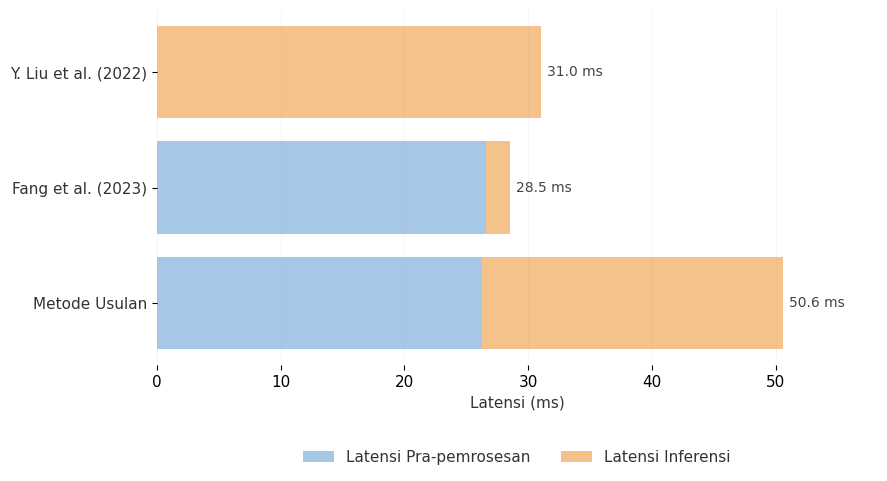

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
studies = [
    "Belaiche et al. (2020)",
    "Y. Liu et al. (2022)",
    "Fang et al. (2023)",
    "Metode Usulan"
]

preprocess = np.array([ 11.8, 0, 26.6, 26.26])
inference  = np.array([12.8, 31, 1.9, 24.33])

y = np.arange(len(studies))

# Style ala "Claude-like minimal"
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans"
})

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")

# Soft color palette
color_pre = "#A7C7E7"   # soft blue
color_inf = "#F6C28B"   # soft orange

# Horizontal stacked bar
ax.barh(y, preprocess, color=color_pre, edgecolor="none", label="Latensi Pra-pemrosesan")
ax.barh(y, inference, left=preprocess, color=color_inf, edgecolor="none", label="Latensi Inferensi")

# Total labels (lebih subtle)
total = preprocess + inference
for i, t in enumerate(total):
    ax.text(t + max(total)*0.01, i, f"{t:.1f} ms",
            va='center', fontsize=10, color="#444444")

# Axis formatting
ax.set_yticks(y)
ax.set_yticklabels(studies, color="#333333")
ax.set_xlabel("Latensi (ms)", color="#333333")

# Clean look: remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Light grid (x-axis only)
ax.xaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.15)
ax.yaxis.grid(False)

ax.invert_yaxis()
ax.set_xlim(0, max(total) * 1.15)

# Minimal legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False,
    labelcolor="#333333"
)

plt.tight_layout()
plt.show()